# Is the 8-band onset predictor worthwhile?

This notebook tests whether adding `gammatone-on-8` improves held-out EEG prediction relative to `gammatone-8` alone.

The comparison is paired by subject:

- Baseline: `gammatone-8`
- Combined: `gammatone-8 + gammatone-on-8`
- Subject score: mean held-out prediction correlation (`tracking_r_mean`) across sensors
- Primary test: two-sided paired t-test across subjects


## Hypotheses

Let $d_i = r_{combined,i} - r_{baseline,i}$ for subject $i$.

- $H_0$: the population mean of $d$ is 0.
- $H_1$: the population mean of $d$ is not 0.

A positive mean difference with a significant paired test supports an incremental contribution from the onset predictor. Statistical significance is interpreted together with the effect size, confidence interval, and the numbers of improved and degraded subjects.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats

# This works when the notebook is launched from this directory or the repo root.
cwd = Path.cwd().resolve()
if (cwd / 'pipeline.py').exists():
    TRF_PIPELINE_DIR = cwd
elif (cwd.parent / 'pipeline.py').exists():
    TRF_PIPELINE_DIR = cwd.parent
else:
    candidate = cwd / 'analysis' / 'trf_pipeline'
    if not (candidate / 'pipeline.py').exists():
        raise FileNotFoundError('Could not locate analysis/trf_pipeline')
    TRF_PIPELINE_DIR = candidate

RESULTS_DIR = TRF_PIPELINE_DIR / 'results'
BASELINE_PATH = RESULTS_DIR / 'by_predictor' / 'gammatone-8' / 'subject_results.csv'
COMBINED_PATH = (
    RESULTS_DIR / 'by_multi_predictor'
    / 'gammatone-8-plus-gammatone-on-8' / 'subject_results.csv'
)
OUTPUT_DIR = RESULTS_DIR / 'statistics'
SUBJECT_OUTPUT_PATH = OUTPUT_DIR / 'gammatone_8_plus_onset_8_subject_deltas.csv'
SUMMARY_OUTPUT_PATH = OUTPUT_DIR / 'gammatone_8_plus_onset_8_paired_ttest.csv'

BASELINE_MODEL = 'gammatone-8'
COMBINED_MODEL = 'gammatone-8 + gammatone-on-8'
METRIC = 'tracking_r_mean'
AUD_MONITOR_UNVERIFIED_SUBJECTS = {'sub-09', 'sub-16'}
BAD_MASTOID_REFERENCE_SUBJECTS = {'sub-11', 'sub-25', 'sub-26', 'sub-48'}
CONTROLLED_COLUMNS = (
    'estimator', 'raw', 'epoch', 'reference', 'inv',
    'tstart', 'tstop', 'samplingrate', 'filter_x',
)

print(f'TRF pipeline directory: {TRF_PIPELINE_DIR}')
print(f'Baseline results: {BASELINE_PATH}')
print(f'Combined results: {COMBINED_PATH}')

TRF pipeline directory: /Users/yanyuwoo/Desktop/mcmaster-project/alice-comprehension-neural-prediction/analysis/trf_pipeline
Baseline results: /Users/yanyuwoo/Desktop/mcmaster-project/alice-comprehension-neural-prediction/analysis/trf_pipeline/results/by_predictor/gammatone-8/subject_results.csv
Combined results: /Users/yanyuwoo/Desktop/mcmaster-project/alice-comprehension-neural-prediction/analysis/trf_pipeline/results/by_multi_predictor/gammatone-8-plus-gammatone-on-8/subject_results.csv


## Load and validate the paired results

The validation below prevents a paired test from silently comparing different subjects or different preprocessing settings.

In [2]:
required_columns = {
    'subject', 'predictor', 'status', 'finite_result',
    'include_trf_primary', 'trf_exclusion_reason', METRIC,
    *CONTROLLED_COLUMNS,
}
baseline = pd.read_csv(BASELINE_PATH, keep_default_na=False)
combined = pd.read_csv(COMBINED_PATH, keep_default_na=False)

for label, table, expected_model in (
    ('baseline', baseline, BASELINE_MODEL),
    ('combined', combined, COMBINED_MODEL),
):
    missing = required_columns - set(table.columns)
    if missing:
        raise ValueError(f'{label} is missing columns: {sorted(missing)}')
    if table['subject'].duplicated().any():
        raise ValueError(f'{label} contains duplicate subjects')
    if table['predictor'].unique().tolist() != [expected_model]:
        raise ValueError(f'{label} does not contain the expected model')

if set(baseline['subject']) != set(combined['subject']):
    raise ValueError('Baseline and combined results contain different subjects')

for column in CONTROLLED_COLUMNS:
    baseline_values = baseline[column].unique().tolist()
    combined_values = combined[column].unique().tolist()
    if len(baseline_values) != 1 or baseline_values != combined_values:
        raise ValueError(
            f'Controlled setting {column!r} differs: '
            f'baseline={baseline_values}, combined={combined_values}'
        )

settings = pd.DataFrame({
    column: [baseline[column].iloc[0]] for column in CONTROLLED_COLUMNS
})
print(f'Validated {len(baseline)} paired subjects')
display(settings)

Validated 49 paired subjects


,estimator,raw,epoch,reference,inv,tstart,tstop,samplingrate,filter_x
0,boosting,0.5-20,story-segments,mastoids,,-0.1,1.0,50,continuous


In [3]:
baseline_paired = baseline[[
    'subject', METRIC, 'status', 'finite_result',
    'include_trf_primary', 'trf_exclusion_reason',
]].rename(columns={
    METRIC: 'tracking_r_gammatone_8',
    'status': 'status_gammatone_8',
    'finite_result': 'finite_gammatone_8',
    'include_trf_primary': 'include_gammatone_8',
    'trf_exclusion_reason': 'exclusion_gammatone_8',
})
combined_paired = combined[[
    'subject', METRIC, 'status', 'finite_result',
    'include_trf_primary', 'trf_exclusion_reason',
]].rename(columns={
    METRIC: 'tracking_r_combined',
    'status': 'status_combined',
    'finite_result': 'finite_combined',
    'include_trf_primary': 'include_combined',
    'trf_exclusion_reason': 'exclusion_combined',
})

paired = baseline_paired.merge(
    combined_paired, on='subject', how='inner', validate='one_to_one'
)
paired['delta_tracking_r'] = (
    paired['tracking_r_combined'] - paired['tracking_r_gammatone_8']
)
paired['outcome'] = np.select(
    [paired['delta_tracking_r'] > 0, paired['delta_tracking_r'] < 0],
    ['improved', 'degraded'], default='unchanged',
)
paired['include_all_finite'] = (
    paired['status_gammatone_8'].eq('ok')
    & paired['status_combined'].eq('ok')
    & paired['finite_gammatone_8']
    & paired['finite_combined']
)
paired['aud_monitor_qc'] = np.where(
    paired['subject'].isin(AUD_MONITOR_UNVERIFIED_SUBJECTS),
    'unverified_invalid_AUD', 'pass',
)
paired['mastoid_reference_qc'] = np.where(
    paired['subject'].isin(BAD_MASTOID_REFERENCE_SUBJECTS), 'fail', 'pass'
)
paired['include_primary'] = paired['include_all_finite']
paired['include_without_invalid_aud'] = (
    paired['include_all_finite'] & paired['aud_monitor_qc'].eq('pass')
)
paired['include_without_bad_mastoid'] = (
    paired['include_all_finite'] & paired['mastoid_reference_qc'].eq('pass')
)
paired['include_strict_qc'] = (
    paired['include_without_invalid_aud']
    & paired['mastoid_reference_qc'].eq('pass')
)
paired['subject_number'] = paired['subject'].str.removeprefix('sub-').astype(int)
paired = paired.sort_values('subject_number').drop(columns='subject_number')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
paired.to_csv(SUBJECT_OUTPUT_PATH, index=False)
print(f'Saved subject-level results: {SUBJECT_OUTPUT_PATH}')
display(paired)

Saved subject-level results: /Users/yanyuwoo/Desktop/mcmaster-project/alice-comprehension-neural-prediction/analysis/trf_pipeline/results/statistics/gammatone_8_plus_onset_8_subject_deltas.csv


,subject,tracking_r_gammatone_8,status_gammatone_8,finite_gammatone_8,include_gammatone_8,exclusion_gammatone_8,tracking_r_combined,status_combined,finite_combined,include_combined,exclusion_combined,delta_tracking_r,outcome,include_all_finite,aud_monitor_qc,mastoid_reference_qc,include_primary,include_without_invalid_aud,include_without_bad_mastoid,include_strict_qc
0,sub-01,0.043644,ok,True,True,,0.048881,ok,True,True,,0.005237,improved,True,pass,pass,True,True,True,True
1,sub-02,0.057938,ok,True,True,,0.056822,ok,True,True,,-0.001116,degraded,True,pass,pass,True,True,True,True
2,sub-03,0.042118,ok,True,True,,0.041565,ok,True,True,,-0.000553,degraded,True,pass,pass,True,True,True,True
3,sub-04,0.011066,ok,True,True,,0.014536,ok,True,True,,0.003470,improved,True,pass,pass,True,True,True,True
4,sub-05,0.029306,ok,True,True,,0.031511,ok,True,True,,0.002204,improved,True,pass,pass,True,True,True,True
5,sub-06,0.027020,ok,True,True,,0.028208,ok,True,True,,0.001187,improved,True,pass,pass,True,True,True,True
6,sub-07,0.054521,ok,True,True,,0.053157,ok,True,True,,-0.001364,degraded,True,pass,pass,True,True,True,True
7,sub-08,0.027316,ok,True,True,,0.029405,ok,True,True,,0.002089,improved,True,pass,pass,True,True,True,True
8,sub-09,0.043720,ok,True,False,audio_alignment_failed,0.043680,ok,True,False,audio_alignment_failed,-0.000040,degraded,True,unverified_invalid_AUD,pass,True,False,True,False
9,sub-10,0.020020,ok,True,True,,0.016541,ok,True,True,,-0.003479,degraded,True,pass,pass,True,True,True,True


## Primary paired t-test

The primary sample includes every subject for whom both models completed with finite paired results. Sub-09 and sub-16 remain in the primary analysis because the TRF models use the precomputed predictors rather than the recorded AUD monitor channel. Their invalid AUD recordings prevent an independent alignment check, but do not by themselves establish a neural/predictor alignment failure.

In [4]:
def summarize_paired_test(name, criterion, table):
    baseline_values = table['tracking_r_gammatone_8'].to_numpy(dtype=float)
    combined_values = table['tracking_r_combined'].to_numpy(dtype=float)
    delta = combined_values - baseline_values
    n_subjects = len(delta)
    df = n_subjects - 1
    mean_delta = delta.mean()
    sd_delta = delta.std(ddof=1)
    standard_error = sd_delta / np.sqrt(n_subjects)
    ci_low, ci_high = stats.t.interval(
        0.95, df, loc=mean_delta, scale=standard_error
    )
    t_two_sided = stats.ttest_rel(combined_values, baseline_values)
    t_greater = stats.ttest_rel(
        combined_values, baseline_values, alternative='greater'
    )
    shapiro = stats.shapiro(delta)
    wilcoxon = stats.wilcoxon(delta, alternative='two-sided')
    n_improved = int((delta > 0).sum())
    n_degraded = int((delta < 0).sum())
    n_unchanged = int((delta == 0).sum())
    sign_test = stats.binomtest(
        n_improved, n_improved + n_degraded, 0.5, alternative='greater'
    )
    baseline_mean = baseline_values.mean()
    return {
        'analysis': name,
        'inclusion_criterion': criterion,
        'n_subjects': n_subjects,
        'baseline_mean_r': baseline_mean,
        'combined_mean_r': combined_values.mean(),
        'mean_delta_r': mean_delta,
        'median_delta_r': np.median(delta),
        'sd_delta_r': sd_delta,
        'mean_relative_change_percent': 100 * mean_delta / baseline_mean,
        'ci_95_low': ci_low,
        'ci_95_high': ci_high,
        'n_improved': n_improved,
        'n_degraded': n_degraded,
        'n_unchanged': n_unchanged,
        'paired_t': t_two_sided.statistic,
        'degrees_of_freedom': df,
        'paired_t_p_two_sided': t_two_sided.pvalue,
        'paired_t_p_greater': t_greater.pvalue,
        'cohen_dz': mean_delta / sd_delta,
        'shapiro_w': shapiro.statistic,
        'shapiro_p': shapiro.pvalue,
        'wilcoxon_w': wilcoxon.statistic,
        'wilcoxon_p_two_sided': wilcoxon.pvalue,
        'sign_test_p_greater': sign_test.pvalue,
        'supports_positive_increment_alpha_0_05': (
            mean_delta > 0 and t_two_sided.pvalue < 0.05
        ),
    }

primary = paired.loc[paired['include_primary']].copy()
primary_result = summarize_paired_test(
    'primary_all_finite',
    'Both models completed with finite paired results',
    primary,
)
pd.Series(primary_result)

analysis                                                                primary_all_finite
inclusion_criterion                       Both models completed with finite paired results
n_subjects                                                                              49
baseline_mean_r                                                                   0.030342
combined_mean_r                                                                   0.031753
mean_delta_r                                                                      0.001412
median_delta_r                                                                    0.001172
sd_delta_r                                                                        0.002427
mean_relative_change_percent                                                      4.652408
ci_95_low                                                                         0.000714
ci_95_high                                                                        0.002109

## Assumption and sensitivity checks

- Shapiro–Wilk evaluates whether the paired differences show a strong departure from normality.
- Wilcoxon signed-rank provides a non-parametric sensitivity check.
- The primary analysis uses all finite paired results, including sub-09 and sub-16.
- The invalid-AUD sensitivity analysis excludes sub-09 and sub-16 because their recorded AUD channels cannot independently verify stimulus alignment; this is not treated as a confirmed TRF failure.
- The bad-mastoid sensitivity analysis excludes sub-11, sub-25, sub-26, and sub-48 from the all-finite sample. Both models use the same reference, but this check verifies that those subjects do not drive the conclusion.
- The strict sensitivity analysis excludes both the invalid-AUD and bad-mastoid sets.

In [5]:
without_invalid_aud = paired.loc[
    paired['include_without_invalid_aud']
].copy()
without_bad_mastoid = paired.loc[
    paired['include_without_bad_mastoid']
].copy()
strict_qc = paired.loc[
    paired['include_strict_qc']
].copy()
summary = pd.DataFrame([
    primary_result,
    summarize_paired_test(
        'exclude_invalid_aud_sensitivity',
        'Exclude subjects whose invalid AUD monitor prevents alignment verification',
        without_invalid_aud,
    ),
    summarize_paired_test(
        'exclude_bad_mastoid_sensitivity',
        'All finite results excluding historical bad mastoid reference flags',
        without_bad_mastoid,
    ),
    summarize_paired_test(
        'strict_qc_sensitivity',
        'Exclude invalid AUD monitor and historical bad mastoid subjects',
        strict_qc,
    ),
])
summary.to_csv(SUMMARY_OUTPUT_PATH, index=False)
print(f'Saved statistical summary: {SUMMARY_OUTPUT_PATH}')
display(summary[[
    'analysis', 'n_subjects', 'baseline_mean_r', 'combined_mean_r',
    'mean_delta_r', 'ci_95_low', 'ci_95_high', 'n_improved',
    'n_degraded', 'paired_t', 'degrees_of_freedom',
    'paired_t_p_two_sided', 'cohen_dz',
]])

Saved statistical summary: /Users/yanyuwoo/Desktop/mcmaster-project/alice-comprehension-neural-prediction/analysis/trf_pipeline/results/statistics/gammatone_8_plus_onset_8_paired_ttest.csv


,analysis,n_subjects,baseline_mean_r,combined_mean_r,mean_delta_r,ci_95_low,ci_95_high,n_improved,n_degraded,paired_t,degrees_of_freedom,paired_t_p_two_sided,cohen_dz
0,primary_all_finite,49,0.030342,0.031753,0.001412,0.000714,0.002109,34,15,4.071298,48,0.000174,0.581614
1,exclude_invalid_aud_sensitivity,47,0.029518,0.030983,0.001465,0.000742,0.002189,33,14,4.076288,46,0.000179,0.594588
2,exclude_bad_mastoid_sensitivity,45,0.031533,0.032782,0.001248,0.000536,0.001960,30,15,3.532822,44,0.000980,0.526642
3,strict_qc_sensitivity,43,0.030689,0.031988,0.001299,0.000557,0.002042,29,14,3.530619,42,0.001021,0.538414


## Which subjects improved or degraded?

In [6]:
improved = primary.loc[
    primary['outcome'].eq('improved'),
    ['subject', 'tracking_r_gammatone_8', 'tracking_r_combined', 'delta_tracking_r'],
].sort_values('delta_tracking_r', ascending=False)
degraded = primary.loc[
    primary['outcome'].eq('degraded'),
    ['subject', 'tracking_r_gammatone_8', 'tracking_r_combined', 'delta_tracking_r'],
].sort_values('delta_tracking_r')

print(f'Improved: {len(improved)} subjects')
display(improved.style.format({
    'tracking_r_gammatone_8': '{:.6f}',
    'tracking_r_combined': '{:.6f}',
    'delta_tracking_r': '{:+.6f}',
}))
print(f'Degraded: {len(degraded)} subjects')
display(degraded.style.format({
    'tracking_r_gammatone_8': '{:.6f}',
    'tracking_r_combined': '{:.6f}',
    'delta_tracking_r': '{:+.6f}',
}))

Improved: 34 subjects


,subject,tracking_r_gammatone_8,tracking_r_combined,delta_tracking_r
22,sub-23,0.014604,0.021476,+0.006872
25,sub-26,0.019798,0.026646,+0.006848
29,sub-30,0.001725,0.007082,+0.005357
14,sub-15,0.058478,0.063745,+0.005267
0,sub-01,0.043644,0.048881,+0.005237
38,sub-39,0.014710,0.019804,+0.005095
45,sub-46,-0.032546,-0.027987,+0.004559
46,sub-47,0.004137,0.008642,+0.004504
48,sub-49,0.015104,0.018625,+0.003521
3,sub-04,0.011066,0.014536,+0.003470


Degraded: 15 subjects


,subject,tracking_r_gammatone_8,tracking_r_combined,delta_tracking_r
9,sub-10,0.020020,0.016541,-0.003479
34,sub-35,0.026063,0.023124,-0.002939
43,sub-44,0.054459,0.052536,-0.001923
39,sub-40,0.026483,0.024946,-0.001538
18,sub-19,0.032970,0.031589,-0.001381
6,sub-07,0.054521,0.053157,-0.001364
1,sub-02,0.057938,0.056822,-0.001116
27,sub-28,0.052551,0.051653,-0.000898
32,sub-33,-0.003397,-0.004067,-0.000669
19,sub-20,0.013059,0.012419,-0.000640


## Paired subject plot

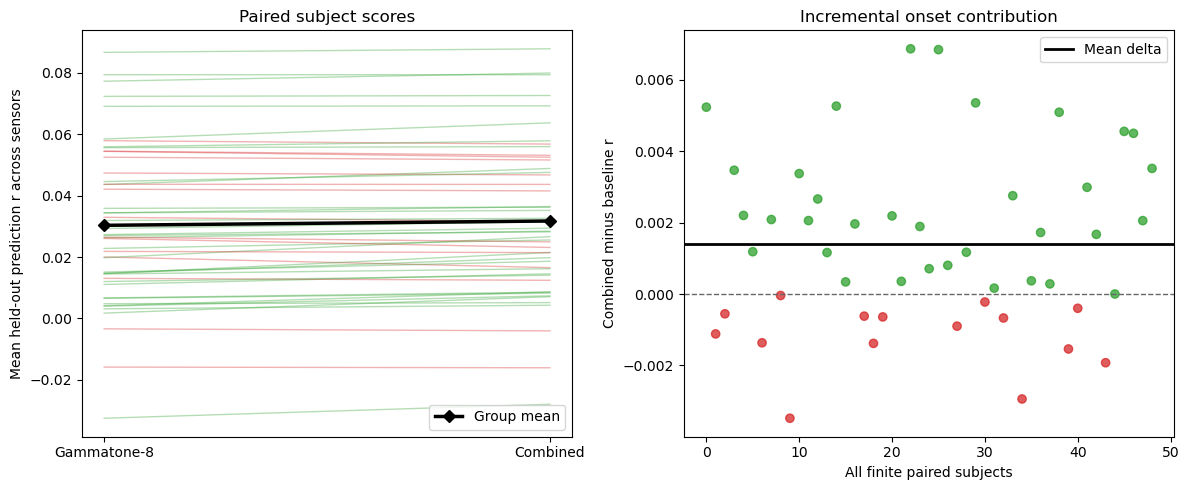

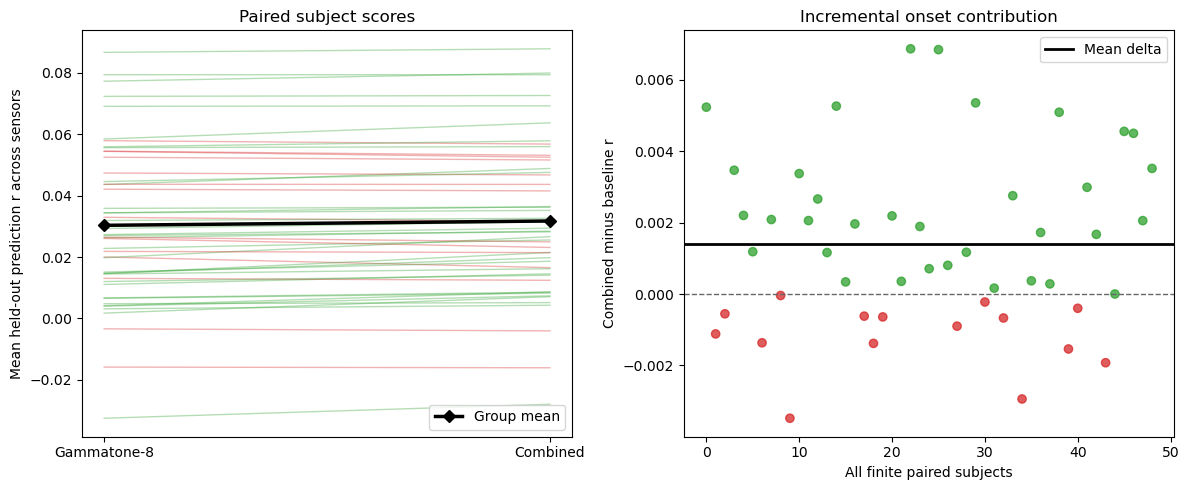

In [7]:
figure, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.array([0, 1])
for row in primary.itertuples():
    values = [row.tracking_r_gammatone_8, row.tracking_r_combined]
    color = 'tab:green' if row.delta_tracking_r > 0 else 'tab:red'
    axes[0].plot(x, values, color=color, alpha=0.35, linewidth=1)
axes[0].plot(
    x,
    [primary['tracking_r_gammatone_8'].mean(), primary['tracking_r_combined'].mean()],
    color='black', marker='D', linewidth=2.5, label='Group mean',
)
axes[0].set_xticks(x, ['Gammatone-8', 'Combined'])
axes[0].set_ylabel('Mean held-out prediction r across sensors')
axes[0].set_title('Paired subject scores')
axes[0].legend()

axes[1].axhline(0, color='0.4', linestyle='--', linewidth=1)
colors = np.where(primary['delta_tracking_r'] > 0, 'tab:green', 'tab:red')
axes[1].scatter(
    np.arange(len(primary)), primary['delta_tracking_r'], c=colors, alpha=0.75
)
axes[1].axhline(
    primary['delta_tracking_r'].mean(), color='black', linewidth=2, label='Mean delta'
)
axes[1].set_xlabel('All finite paired subjects')
axes[1].set_ylabel('Combined minus baseline r')
axes[1].set_title('Incremental onset contribution')
axes[1].legend()

figure.tight_layout()
figure

## Data-driven conclusion

In [8]:
result = summary.set_index('analysis').loc['primary_all_finite']
decision = (
    'supports retaining the onset predictor'
    if result['supports_positive_increment_alpha_0_05']
    else 'does not provide sufficient evidence to retain the onset predictor'
)
print(
    f"The primary paired comparison {decision}.\n"
    f"Mean r: {result['baseline_mean_r']:.5f} -> {result['combined_mean_r']:.5f}\n"
    f"Mean delta r: {result['mean_delta_r']:+.6f} "
    f"(95% CI {result['ci_95_low']:.6f} to {result['ci_95_high']:.6f})\n"
    f"Paired t({int(result['degrees_of_freedom'])}) = {result['paired_t']:.3f}, "
    f"two-sided p = {result['paired_t_p_two_sided']:.6g}, "
    f"Cohen's dz = {result['cohen_dz']:.3f}\n"
    f"Improved: {int(result['n_improved'])}/{int(result['n_subjects'])}; "
    f"degraded: {int(result['n_degraded'])}/{int(result['n_subjects'])}."
)


The primary paired comparison supports retaining the onset predictor.
Mean r: 0.03034 -> 0.03175
Mean delta r: +0.001412 (95% CI 0.000714 to 0.002109)
Paired t(48) = 4.071, two-sided p = 0.000173848, Cohen's dz = 0.582
Improved: 34/49; degraded: 15/49.
